# Neural cascade

Final full run for the restarted neural cascade with \(N=2\) and \(N=3\).

The notebook trains the cascade from scratch, saves the retained models and tables, and produces the final validation figures.

## Setup

In [1]:
from __future__ import annotations

import copy
import math
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from torch import Tensor, nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
SEED = 123

RESULTS = Path("cascade_results")
RESULTS.mkdir(parents=True, exist_ok=True)

print("device", DEVICE)

device cuda


In [2]:
@dataclass(frozen=True)
class Config:
    T: float = 1.0
    sigma: float = 1.0
    alpha: float = 1.0

    x_min: float = 1.0
    n2_x_max: float = 4.0
    n3_x_max: float = 7.0
    max_restart_time: float = 0.95

    steps: int = 40
    restart_levels: int = 41

    width: int = 64
    depth: int = 3
    iterations: int = 15_000
    batch_size: int = 1_024
    validation_size: int = 8_192

    learning_rate: float = 1.0e-3
    scheduler_step: int = 1_000
    scheduler_gamma: float = 0.95
    validation_every: int = 200
    display_every: int = 1_000
    gradient_clip: float = 10.0

    living_weight: float = 0.10
    exit_weight: float = 0.10
    range_weight: float = 0.05
    monotonicity_weight: float = 0.25

    terminal_epsilon: float = 0.01
    terminal_margin: float = 0.05

    boundary_zero_tol: float = 5.0e-5
    boundary_other_margin: float = 1.0e-4
    boundary_rounds: int = 400
    boundary_multiplier: int = 4

    validation_times: tuple[float, ...] = (0.0, 0.5, 0.9, 0.95)

    reference_grid: int = 51
    reference_paths: int = 2_048
    reference_coarse_steps: int = 40
    reference_fine_steps: int = 400
    reference_point_batch: int = 32

    projection_samples: int = 4_096


CFG = Config()

## Helpers

In [3]:
def seed_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_generator(seed: int) -> torch.Generator:
    try:
        g = torch.Generator(device=DEVICE)
    except TypeError:
        g = torch.Generator()
    g.manual_seed(seed)
    return g

def uniform(shape, low, high, generator):
    return low + (high - low) * torch.rand(
        shape,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )

def normal_cdf(x: Tensor) -> Tensor:
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))

def normal_pdf(x: Tensor) -> Tensor:
    return torch.exp(-0.5 * x.square()) / math.sqrt(2.0 * math.pi)

def to_numpy(x: Tensor) -> np.ndarray:
    return x.detach().cpu().numpy()

def masked_mean(x: Tensor, mask: Tensor) -> Tensor:
    if bool(mask.any()):
        return x[mask].mean()
    return x.sum() * 0.0

def first_true(mask: Tensor):
    hit = mask.any(dim=1)
    index = mask.to(torch.int64).argmax(dim=1)
    last = mask.shape[1] - 1
    index = torch.where(hit, index, torch.full_like(index, last))
    return index, hit

def show_table(table: pd.DataFrame, decimals: int = 4) -> None:
    display(table.round(decimals).style.hide(axis="index"))

## Value network

In [4]:
class MLP(nn.Module):
    def __init__(self, inputs: int, width: int, depth: int):
        super().__init__()
        layers = []
        current = inputs
        for _ in range(depth):
            layers += [nn.Linear(current, width), nn.Softplus()]
            current = width
        layers.append(nn.Linear(current, 1))
        self.net = nn.Sequential(*layers)

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x: Tensor) -> Tensor:
        return self.net(x)[:, 0]


class ValueNet(nn.Module):
    def __init__(self, n: int, level: int, x_max: float):
        super().__init__()
        self.n = n
        self.level = level
        self.x_max = x_max

        self.time_center = 0.5
        self.time_scale = 0.5
        self.x_center = 0.5 * (CFG.x_min + x_max)
        self.x_scale = 0.5 * (x_max - CFG.x_min)

        self.net = MLP(
            1 + level,
            CFG.width,
            CFG.depth,
        )

    def features(self, t: float | Tensor, x: Tensor) -> Tensor:
        if self.level == 1:
            x = x.reshape(-1, 1)

        t = torch.as_tensor(t, device=x.device, dtype=x.dtype)
        if t.ndim == 0:
            t = t.expand(x.shape[0])
        t = t.reshape(-1, 1)

        sorted_x = torch.sort(x, dim=1).values

        t_feature = (t - self.time_center) / self.time_scale
        x_feature = (sorted_x - self.x_center) / self.x_scale

        return torch.cat((t_feature, x_feature), dim=1)

    def value(self, t: float | Tensor, x: Tensor) -> Tensor:
        return self.net(self.features(t, x))

    def value_and_z(
        self,
        t: float | Tensor,
        x: Tensor,
        create_graph: bool,
    ):
        if self.level == 1:
            x = x.reshape(-1, 1)

        x_var = x.detach().clone().requires_grad_(True)
        value = self.value(t, x_var)

        grad = torch.autograd.grad(
            value.sum(),
            x_var,
            create_graph=create_graph,
        )[0]

        z = CFG.sigma * grad
        return value, z

The value network uses time and the sorted living coordinates. The martingale coefficient is computed as
\(Z=\sigma
abla_x v\), so there is no separate \(Z\) network.

## Brownian paths

In [5]:
@dataclass
class Batch:
    start_time: Tensor
    times: Tensor
    x0: Tensor
    paths: Tensor
    dW: Tensor
    bridge_u: Tensor


def restart_times(size: int, generator: torch.Generator) -> Tensor:
    grid = torch.linspace(
        0.0,
        CFG.max_restart_time,
        CFG.restart_levels,
        device=DEVICE,
        dtype=DTYPE,
    )
    repeats = math.ceil(size / len(grid))
    times = grid.repeat(repeats)[:size]
    order = torch.randperm(size, generator=generator, device=DEVICE)
    return times[order]


def sample_batch(
    batch_size: int,
    level: int,
    x_max: float,
    generator: torch.Generator,
    antithetic: bool,
) -> Batch:
    if antithetic and batch_size % 2:
        raise ValueError("batch size must be even")

    base = batch_size // 2 if antithetic else batch_size

    start = restart_times(base, generator)
    x0 = uniform((base, level), CFG.x_min, x_max, generator)
    normal = torch.randn(
        base,
        CFG.steps,
        level,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )
    bridge_u = torch.rand(
        base,
        CFG.steps,
        level,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )

    if antithetic:
        start = torch.cat((start, start.clone()))
        x0 = torch.cat((x0, x0.clone()))
        normal = torch.cat((normal, -normal))
        bridge_u = torch.cat((bridge_u, bridge_u.clone()))

    dt = (CFG.T - start) / CFG.steps
    dW = torch.sqrt(dt)[:, None, None] * normal

    zero = torch.zeros(
        batch_size,
        1,
        level,
        device=DEVICE,
        dtype=DTYPE,
    )

    paths = x0[:, None, :] + CFG.sigma * torch.cat(
        (zero, dW.cumsum(dim=1)),
        dim=1,
    )

    fraction = torch.arange(
        CFG.steps + 1,
        device=DEVICE,
        dtype=DTYPE,
    )[None, :] / CFG.steps

    times = start[:, None] + (CFG.T - start)[:, None] * fraction

    return Batch(start, times, x0, paths, dW, bridge_u)

## Exact singleton

In [6]:
@torch.no_grad()
def exact_singleton(n: int, t: float | Tensor, x: Tensor) -> Tensor:
    t = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t, x = torch.broadcast_tensors(t, x)

    threshold = CFG.alpha * n
    remaining = CFG.T - t

    terminal = torch.where(
        x <= threshold,
        torch.full_like(x, float(n)),
        torch.full_like(x, float(n - 1)),
    )

    safe = remaining.clamp_min(torch.finfo(x.dtype).eps)
    arg = torch.minimum(
        (threshold - x) / (CFG.sigma * torch.sqrt(safe)),
        torch.zeros_like(x),
    )

    value = float(n - 1) + 2.0 * normal_cdf(arg)

    return torch.where(remaining <= 1.0e-12, terminal, value)


@torch.no_grad()
def exact_singleton_z(n: int, t: float | Tensor, x: Tensor) -> Tensor:
    t = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t, x = torch.broadcast_tensors(t, x)

    threshold = CFG.alpha * n
    remaining = CFG.T - t
    safe = remaining.clamp_min(torch.finfo(x.dtype).eps)

    arg = (threshold - x) / (CFG.sigma * torch.sqrt(safe))
    z = -2.0 * normal_pdf(arg) / torch.sqrt(safe)

    return torch.where(
        (x <= threshold) | (remaining <= 1.0e-12),
        torch.zeros_like(x),
        z,
    )

## Completion and boundary

In [7]:
@torch.no_grad()
def completed_value(
    n: int,
    level: int,
    t: float | Tensor,
    x: Tensor,
    models: dict[int, object],
) -> Tensor:
    if level == 0:
        return torch.full(
            (x.shape[0],),
            float(n),
            device=x.device,
            dtype=x.dtype,
        )

    if level == 1:
        raw = models[1].value(t, x[:, 0])

        tt = torch.as_tensor(t, device=x.device, dtype=x.dtype)
        if tt.ndim == 0:
            tt = tt.expand(x.shape[0])

        terminal = torch.full_like(raw, float(n - 1))
        raw = torch.where(tt >= CFG.T - 1.0e-10, terminal, raw)

        threshold = CFG.alpha * n
        return torch.where(
            x[:, 0] <= threshold,
            torch.full_like(raw, float(n)),
            raw,
        )

    raw = models[level].value(t, x)

    tt = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    if tt.ndim == 0:
        tt = tt.expand(x.shape[0])

    lower_raw = []
    margins = []

    for i in range(level):
        reduced = torch.cat((x[:, :i], x[:, i + 1:]), dim=1)

        lower = completed_value(
            n,
            level - 1,
            t,
            reduced,
            models,
        )

        lower_for_boundary = lower.clamp(
            float(n - level + 1),
            float(n),
        )

        lower_raw.append(lower)
        margins.append(
            x[:, i] - CFG.alpha * lower_for_boundary
        )

    lower_raw = torch.stack(lower_raw, dim=1)
    margins = torch.stack(margins, dim=1)

    in_domain = (margins > 0.0).all(dim=1)
    selected = margins.argmin(dim=1)

    boundary_value = lower_raw.gather(
        1,
        selected[:, None],
    )[:, 0]

    terminal = torch.full_like(raw, float(n - level))
    raw = torch.where(tt >= CFG.T - 1.0e-10, terminal, raw)

    return torch.where(in_domain, raw, boundary_value)


@torch.no_grad()
def margins_at(
    n: int,
    level: int,
    t: float | Tensor,
    x: Tensor,
    lower_models: dict[int, object],
) -> Tensor:
    if level == 1:
        return x[:, 0:1] - CFG.alpha * n

    margins = []

    for i in range(level):
        reduced = torch.cat((x[:, :i], x[:, i + 1:]), dim=1)

        lower = completed_value(
            n,
            level - 1,
            t,
            reduced,
            lower_models,
        )

        lower_for_boundary = lower.clamp(
            float(n - level + 1),
            float(n),
        )

        margins.append(
            x[:, i] - CFG.alpha * lower_for_boundary
        )

    return torch.stack(margins, dim=1)


@torch.no_grad()
def in_domain(
    n: int,
    level: int,
    t: float | Tensor,
    x: Tensor,
    lower_models: dict[int, object],
) -> Tensor:
    return (margins_at(n, level, t, x, lower_models) > 0.0).all(dim=1)

Frozen lower level values are clipped only when they define the next moving boundary. The unclipped completed value is still used as the value at exit.

## Brownian bridge stopping

In [8]:
@torch.no_grad()
def stop_target(
    n: int,
    level: int,
    batch: Batch,
    lower_models: dict[int, object],
    use_bridge: bool,
):
    b, nodes, _ = batch.paths.shape

    all_margins = []
    all_lower = []

    flat_t = batch.times.reshape(-1)

    if level == 1:
        margin = batch.paths[:, :, 0] - CFG.alpha * n
        all_margins = margin[:, :, None]
        all_lower = torch.full_like(all_margins, float(n))
    else:
        margin_list = []
        lower_list = []

        for i in range(level):
            reduced = torch.cat(
                (
                    batch.paths[:, :, :i],
                    batch.paths[:, :, i + 1:],
                ),
                dim=2,
            ).reshape(-1, level - 1)

            lower = completed_value(
                n,
                level - 1,
                flat_t,
                reduced,
                lower_models,
            ).reshape(b, nodes)

            lower_for_boundary = lower.clamp(
                float(n - level + 1),
                float(n),
            )

            margin_list.append(
                batch.paths[:, :, i] - CFG.alpha * lower_for_boundary
            )
            lower_list.append(lower)

        all_margins = torch.stack(margin_list, dim=2)
        all_lower = torch.stack(lower_list, dim=2)

    immediate = all_margins[:, 0] <= 0.0

    if use_bridge:
        left = all_margins[:, :-1]
        right = all_margins[:, 1:]

        endpoint_hit = right <= 0.0
        both_above = (left > 0.0) & (right > 0.0)

        dt = ((CFG.T - batch.start_time) / CFG.steps)[:, None, None]

        q = torch.where(
            both_above,
            torch.exp(
                -2.0
                * left.clamp_min(0.0)
                * right.clamp_min(0.0)
                / (CFG.sigma**2 * dt.clamp_min(torch.finfo(DTYPE).eps))
            ).clamp(0.0, 1.0),
            torch.zeros_like(left),
        )

        interval_fire = endpoint_hit | (both_above & (batch.bridge_u <= q))
    else:
        interval_fire = all_margins[:, 1:] <= 0.0

    fired = torch.zeros(
        b,
        nodes,
        level,
        device=DEVICE,
        dtype=torch.bool,
    )
    fired[:, 0] = immediate
    fired[:, 1:] = interval_fire

    node_exit = fired.any(dim=2)
    stop_index, hit = first_true(node_exit)

    row = torch.arange(b, device=DEVICE)
    stop_margins = all_margins[row, stop_index]
    stop_fired = fired[row, stop_index]

    masked = torch.where(
        stop_fired,
        stop_margins,
        torch.full_like(stop_margins, math.inf),
    )
    selected = masked.argmin(dim=1)

    lower_at_stop = all_lower[row, stop_index]
    exit_value = lower_at_stop.gather(
        1,
        selected[:, None],
    )[:, 0]

    terminal = torch.full_like(exit_value, float(n - level))
    target = torch.where(hit, exit_value, terminal)

    return stop_index, target, hit

## Training data

In [9]:
@torch.no_grad()
def sample_boundary(
    n: int,
    level: int,
    x_max: float,
    lower_models: dict[int, object],
    generator: torch.Generator,
    size: int,
):
    if level == 1:
        t = restart_times(size, generator)
        point = torch.full(
            (size, 1),
            CFG.alpha * n,
            device=DEVICE,
            dtype=DTYPE,
        )
        target = torch.full(
            (size,),
            float(n),
            device=DEVICE,
            dtype=DTYPE,
        )
        return t, point, target

    times = []
    points = []
    targets = []
    needed = size

    for _ in range(CFG.boundary_rounds):
        if needed <= 0:
            break

        proposal = max(CFG.boundary_multiplier * needed, 128)

        t = restart_times(proposal, generator)
        survivor = uniform(
            (proposal, level - 1),
            CFG.x_min,
            x_max,
            generator,
        )

        keep = in_domain(
            n,
            level - 1,
            t,
            survivor,
            lower_models,
        )

        if not bool(keep.any()):
            continue

        t = t[keep]
        survivor = survivor[keep]

        lower = completed_value(
            n,
            level - 1,
            t,
            survivor,
            lower_models,
        )

        lower_for_boundary = lower.clamp(
            float(n - level + 1),
            float(n),
        )

        point = torch.cat(
            ((CFG.alpha * lower_for_boundary)[:, None], survivor),
            dim=1,
        )

        current = margins_at(
            n,
            level,
            t,
            point,
            lower_models,
        )

        valid = (
            (current[:, 0].abs() <= CFG.boundary_zero_tol)
            & (current[:, 1:] > CFG.boundary_other_margin).all(dim=1)
        )

        if not bool(valid.any()):
            continue

        rows = valid.nonzero(as_tuple=False).flatten()[:needed]

        times.append(t[rows])
        points.append(point[rows])
        targets.append(lower[rows])
        needed -= len(rows)

    if needed > 0:
        raise RuntimeError("not enough boundary points")

    t = torch.cat(times)[:size]
    point = torch.cat(points)[:size]
    target = torch.cat(targets)[:size]

    keys = torch.rand(
        size,
        level,
        generator=generator,
        device=DEVICE,
        dtype=DTYPE,
    )
    order = keys.argsort(dim=1)
    point = point.gather(1, order)

    return t, point, target


@torch.no_grad()
def sample_terminal_points(
    n: int,
    level: int,
    x_max: float,
    lower_models: dict[int, object],
    generator: torch.Generator,
    size: int,
) -> Tensor:
    t = CFG.T - CFG.terminal_epsilon

    if level == 1:
        low = CFG.alpha * n + CFG.terminal_margin
        return uniform((size, 1), low, x_max, generator)

    accepted = []
    needed = size

    for _ in range(200):
        if needed <= 0:
            break

        proposal = max(4 * needed, 128)
        x = uniform((proposal, level), CFG.x_min, x_max, generator)

        margin = margins_at(
            n,
            level,
            t,
            x,
            lower_models,
        )

        keep = (margin > CFG.terminal_margin).all(dim=1)

        if bool(keep.any()):
            rows = keep.nonzero(as_tuple=False).flatten()[:needed]
            accepted.append(x[rows])
            needed -= len(rows)

    if needed > 0:
        raise RuntimeError("not enough terminal points")

    return torch.cat(accepted)[:size]


def sample_level_data(
    n: int,
    level: int,
    x_max: float,
    lower_models: dict[int, object],
    generator: torch.Generator,
    batch_size: int,
    antithetic: bool,
):
    batch = sample_batch(
        batch_size,
        level,
        x_max,
        generator,
        antithetic,
    )

    boundary = sample_boundary(
        n,
        level,
        x_max,
        lower_models,
        generator,
        batch_size,
    )

    terminal = sample_terminal_points(
        n,
        level,
        x_max,
        lower_models,
        generator,
        batch_size,
    )

    shape_t = restart_times(batch_size, generator)
    shape_x = uniform(
        (batch_size, level),
        CFG.x_min,
        x_max,
        generator,
    )

    return batch, boundary, terminal, shape_t, shape_x

## Loss

In [10]:
def path_values_and_z(model: ValueNet, batch: Batch):
    b, nodes, level = batch.paths.shape

    flat_t = batch.times.reshape(-1)
    flat_x = batch.paths.reshape(-1, level)

    value, z = model.value_and_z(
        flat_t,
        flat_x,
        create_graph=model.training,
    )

    return (
        value.reshape(b, nodes),
        z.reshape(b, nodes, level),
    )


def level_loss(
    n: int,
    level: int,
    model: ValueNet,
    lower_models: dict[int, object],
    data,
    use_bridge: bool,
):
    batch, boundary, terminal_x, shape_t, shape_x = data

    with torch.no_grad():
        stop_index, target, hit = stop_target(
            n,
            level,
            batch,
            lower_models,
            use_bridge,
        )

    values, z = path_values_and_z(model, batch)

    increment = (
        z[:, :-1] * batch.dW
    ).sum(dim=2)

    interval_index = torch.arange(
        CFG.steps,
        device=DEVICE,
    )[None, :]

    before_stop = interval_index < stop_index[:, None]

    stopped = values[:, 0] + (
        increment * before_stop.to(DTYPE)
    ).sum(dim=1)

    stopped_loss = (stopped - target).square().mean()

    living = (~hit)[:, None] | (
        (interval_index + 1) < stop_index[:, None]
    )
    exit_interval = hit[:, None] & (
        (interval_index + 1) == stop_index[:, None]
    )

    one_step = values[:, :-1] + increment

    living_loss = masked_mean(
        (one_step - values[:, 1:]).square(),
        living,
    )

    exit_loss = masked_mean(
        (one_step - target[:, None]).square(),
        exit_interval,
    )

    boundary_t, boundary_x, boundary_target = boundary
    boundary_value = model.value(boundary_t, boundary_x)
    boundary_loss = (
        boundary_value - boundary_target
    ).square().mean()

    terminal_t = CFG.T - CFG.terminal_epsilon
    terminal_value = model.value(terminal_t, terminal_x)
    terminal_target = float(n - level)

    terminal_loss = (
        terminal_value - terminal_target
    ).square().mean()

    with torch.no_grad():
        shape_mask = in_domain(
            n,
            level,
            shape_t,
            shape_x,
            lower_models,
        )

    shape_value, shape_z = model.value_and_z(
        shape_t,
        shape_x,
        create_graph=model.training,
    )

    range_penalty = (
        torch.relu(float(n - level) - shape_value).square()
        + torch.relu(shape_value - float(n)).square()
    )

    range_loss = masked_mean(range_penalty, shape_mask)

    gradient = shape_z / CFG.sigma
    monotonicity_penalty = torch.relu(gradient).square().sum(dim=1)
    monotonicity_loss = masked_mean(
        monotonicity_penalty,
        shape_mask,
    )

    total = (
        stopped_loss
        + CFG.living_weight * living_loss
        + CFG.exit_weight * exit_loss
        + boundary_loss
        + terminal_loss
        + CFG.range_weight * range_loss
        + CFG.monotonicity_weight * monotonicity_loss
    )

    parts = {
        "stopped": stopped_loss,
        "living": living_loss,
        "exit": exit_loss,
        "boundary": boundary_loss,
        "near_terminal": terminal_loss,
        "range": range_loss,
        "monotonicity": monotonicity_loss,
    }

    return total, parts

## Training

In [11]:
@dataclass
class TrainResult:
    best_iteration: int
    best_loss: float
    history: pd.DataFrame


def train_level(
    n: int,
    level: int,
    x_max: float,
    lower_models: dict[int, object],
    seed: int,
    use_bridge: bool,
    name: str,
):
    seed_all(seed)

    model = ValueNet(n, level, x_max).to(DEVICE)

    train_g = make_generator(seed + 1)
    val_g = make_generator(seed + 2)

    val_data = sample_level_data(
        n,
        level,
        x_max,
        lower_models,
        val_g,
        CFG.validation_size,
        False,
    )

    optimiser = torch.optim.Adam(
        model.parameters(),
        lr=CFG.learning_rate,
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        optimiser,
        step_size=CFG.scheduler_step,
        gamma=CFG.scheduler_gamma,
    )

    best_loss = math.inf
    best_iteration = 0
    best_state = copy.deepcopy(model.state_dict())
    rows = []

    for iteration in range(1, CFG.iterations + 1):
        model.train()

        data = sample_level_data(
            n,
            level,
            x_max,
            lower_models,
            train_g,
            CFG.batch_size,
            True,
        )

        optimiser.zero_grad(set_to_none=True)

        loss, _ = level_loss(
            n,
            level,
            model,
            lower_models,
            data,
            use_bridge,
        )

        if not torch.isfinite(loss):
            raise FloatingPointError(name)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            CFG.gradient_clip,
        )
        optimiser.step()
        scheduler.step()

        if iteration % CFG.validation_every == 0 or iteration == CFG.iterations:
            model.eval()

            with torch.enable_grad():
                val_loss, parts = level_loss(
                    n,
                    level,
                    model,
                    lower_models,
                    val_data,
                    use_bridge,
                )

            value = float(val_loss.detach().cpu())

            row = {
                "iteration": iteration,
                "validation": value,
            }
            for key, item in parts.items():
                row[key] = float(item.detach().cpu())
            rows.append(row)

            if value < best_loss:
                best_loss = value
                best_iteration = iteration
                best_state = copy.deepcopy(model.state_dict())

            if iteration % CFG.display_every == 0 or iteration == CFG.iterations:
                print(name, iteration, f"{value:.4e}")

    model.load_state_dict(best_state)
    model.eval()

    for p in model.parameters():
        p.requires_grad_(False)

    result = TrainResult(
        best_iteration,
        best_loss,
        pd.DataFrame(rows),
    )

    return model, result


def train_cascade(n: int, x_max: float, seed: int):
    models = {}
    training = {}

    for level in range(1, n + 1):
        lower = {k: v for k, v in models.items() if k < level}

        model, result = train_level(
            n,
            level,
            x_max,
            lower,
            seed + 100 * level,
            True,
            f"N {n} level {level}",
        )

        models[level] = model
        training[level] = result

    return models, training

In [12]:
@torch.no_grad()
def singleton_table(n: int, model: ValueNet, x_max: float) -> pd.DataFrame:
    threshold = CFG.alpha * n
    x = torch.linspace(
        threshold + 0.001,
        x_max,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )

    rows = []

    for t in CFG.validation_times:
        learned = model.value(t, x)
        exact = exact_singleton(n, t, x)

        with torch.enable_grad():
            _, z = model.value_and_z(
                t,
                x[:, None],
                create_graph=False,
            )

        exact_z = exact_singleton_z(n, t, x)
        error = learned - exact

        rows.append({
            "time": t,
            "MAE": error.abs().mean().item(),
            "RMSE": error.square().mean().sqrt().item(),
            "max error": error.abs().max().item(),
            "signed mean": error.mean().item(),
            "Z MAE": (z[:, 0] - exact_z).abs().mean().item(),
        })

    return pd.DataFrame(rows)


def training_table(n: int, training: dict[int, TrainResult]) -> pd.DataFrame:
    rows = []

    for level, result in training.items():
        best = result.history.loc[
            result.history["validation"].idxmin()
        ]

        row = {
            "N": n,
            "level": level,
            "best iteration": result.best_iteration,
            "best validation": result.best_loss,
        }

        for key in (
            "stopped",
            "living",
            "exit",
            "boundary",
            "near_terminal",
            "range",
            "monotonicity",
        ):
            row[key] = float(best[key])

        rows.append(row)

    return pd.DataFrame(rows)


def save_training(n: int, training: dict[int, TrainResult]) -> None:
    for level, result in training.items():
        result.history.to_csv(
            RESULTS / f"N{n}_level{level}_history.csv",
            index=False,
        )


@torch.no_grad()
def kink_check(
    n: int,
    level: int,
    models: dict[int, object],
    x_max: float,
    samples: int = 1_000_000,
    tol: float = 0.05,
):
    g = make_generator(SEED + 30_000 + 100 * n + level)

    t = restart_times(samples, g)
    x = uniform(
        (samples, level),
        CFG.x_min,
        x_max,
        g,
    )

    values = []
    margins = []

    for i in range(level):
        reduced = torch.cat(
            (x[:, :i], x[:, i + 1:]),
            dim=1,
        )

        lower = completed_value(
            n,
            level - 1,
            t,
            reduced,
            models,
        )

        geometry = lower.clamp(
            float(n - level + 1),
            float(n),
        )

        values.append(lower)
        margins.append(
            x[:, i] - CFG.alpha * geometry
        )

    values = torch.stack(values, dim=1)
    margins = torch.stack(margins, dim=1)

    near = (margins <= 0.0) & (margins >= -tol)
    kink = near.sum(dim=1) >= 2
    count = int(kink.sum().item())

    if count == 0:
        return {
            "N": n,
            "level": level,
            "near kink points": 0,
            "mean spread": math.nan,
            "max spread": math.nan,
        }

    values = values[kink]
    near = near[kink]

    low = torch.where(
        near,
        values,
        torch.full_like(values, math.inf),
    ).min(dim=1).values

    high = torch.where(
        near,
        values,
        torch.full_like(values, -math.inf),
    ).max(dim=1).values

    spread = high - low

    return {
        "N": n,
        "level": level,
        "near kink points": count,
        "mean spread": spread.mean().item(),
        "max spread": spread.max().item(),
    }

## N2

The grid monitored singleton is trained only as a comparison. The main \(N=2\) cascade uses Brownian bridge stopping.

In [13]:
grid_singleton, grid_singleton_training = train_level(
    2,
    1,
    CFG.n2_x_max,
    {},
    SEED + 100,
    False,
    "N 2 singleton grid",
)

models2, training2 = train_cascade(
    2,
    CFG.n2_x_max,
    SEED,
)

torch.save(
    grid_singleton.state_dict(),
    RESULTS / "N2_singleton_grid.pt",
)
for level, model in models2.items():
    torch.save(
        model.state_dict(),
        RESULTS / f"N2_level{level}.pt",
    )

N 2 singleton grid 1000 1.4605e-01
N 2 singleton grid 2000 7.1420e-02
N 2 singleton grid 3000 3.6330e-02
N 2 singleton grid 4000 2.6661e-02
N 2 singleton grid 5000 1.9802e-02
N 2 singleton grid 6000 1.5261e-02
N 2 singleton grid 7000 1.3200e-02
N 2 singleton grid 8000 1.2156e-02
N 2 singleton grid 9000 1.2449e-02
N 2 singleton grid 10000 1.0776e-02
N 2 singleton grid 11000 1.1000e-02
N 2 singleton grid 12000 1.0168e-02
N 2 singleton grid 13000 1.0255e-02
N 2 singleton grid 14000 9.9147e-03
N 2 singleton grid 15000 9.8309e-03
N 2 level 1 1000 1.4837e-01
N 2 level 1 2000 7.0913e-02
N 2 level 1 3000 3.8827e-02
N 2 level 1 4000 2.7761e-02
N 2 level 1 5000 2.2279e-02
N 2 level 1 6000 2.0731e-02
N 2 level 1 7000 1.9022e-02
N 2 level 1 8000 1.5101e-02
N 2 level 1 9000 1.3594e-02
N 2 level 1 10000 1.4665e-02
N 2 level 1 11000 1.2476e-02
N 2 level 1 12000 1.1049e-02
N 2 level 1 13000 1.0442e-02
N 2 level 1 14000 1.1853e-02
N 2 level 1 15000 9.9673e-03
N 2 level 2 1000 3.2049e-01
N 2 level 2 200

In [14]:
save_training(2, training2)
grid_singleton_training.history.to_csv(
    RESULTS / "N2_singleton_grid_history.csv",
    index=False,
)

n2_training = training_table(2, training2)
show_table(n2_training)

n2_training.to_csv(
    RESULTS / "N2_training_table.csv",
    index=False,
)

N,level,best iteration,best validation,stopped,living,exit,boundary,near_terminal,range,monotonicity
2,1,15000,0.010000,0.006400,0.000200,0.023900,0.000600,0.000600,0.000000,0.000000
2,2,15000,0.021900,0.015600,0.000400,0.032700,0.001600,0.001400,0.000000,0.000000


### Singleton monitoring check

In [15]:
@torch.no_grad()
def singleton_table(n: int, model: ValueNet, x_max: float):
    threshold = CFG.alpha * n
    x = torch.linspace(
        threshold + 0.001,
        x_max,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )

    rows = []

    for t in CFG.validation_times:
        learned = model.value(t, x)
        exact = exact_singleton(n, t, x)

        with torch.enable_grad():
            _, z = model.value_and_z(
                t,
                x[:, None],
                create_graph=False,
            )

        exact_z = exact_singleton_z(n, t, x)
        error = learned - exact

        rows.append({
            "time": t,
            "MAE": error.abs().mean().item(),
            "RMSE": error.square().mean().sqrt().item(),
            "max error": error.abs().max().item(),
            "signed mean": error.mean().item(),
            "Z MAE": (z[:, 0] - exact_z).abs().mean().item(),
        })

    return pd.DataFrame(rows)


grid_metrics = singleton_table(
    2,
    grid_singleton,
    CFG.n2_x_max,
)

bridge_metrics = singleton_table(
    2,
    models2[1],
    CFG.n2_x_max,
)

beta = 0.5826

rows = []
x = torch.linspace(
    2.001,
    CFG.n2_x_max,
    800,
    device=DEVICE,
    dtype=DTYPE,
)

for t in CFG.validation_times:
    remaining = CFG.T - t
    shift = beta * CFG.sigma * math.sqrt(remaining / CFG.steps)

    if remaining <= 1.0e-12:
        predicted = exact_singleton(2, t, x)
    else:
        arg = torch.minimum(
            (
                CFG.alpha * 2
                - shift
                - x
            ) / (
                CFG.sigma * math.sqrt(remaining)
            ),
            torch.zeros_like(x),
        )
        predicted = 1.0 + 2.0 * normal_cdf(arg)

    exact = exact_singleton(2, t, x)
    rows.append({
        "time": t,
        "predicted grid MAE": (predicted - exact).abs().mean().item(),
    })

bias_table = pd.DataFrame(rows)

singleton_comparison = (
    grid_metrics[["time", "MAE"]]
    .rename(columns={"MAE": "grid MAE"})
    .merge(
        bridge_metrics[["time", "MAE"]].rename(columns={"MAE": "bridge MAE"}),
        on="time",
    )
    .merge(bias_table, on="time")
)

singleton_comparison["grid over bridge"] = (
    singleton_comparison["grid MAE"]
    / singleton_comparison["bridge MAE"]
)

show_table(singleton_comparison)
singleton_comparison.to_csv(
    RESULTS / "N2_singleton_monitoring.csv",
    index=False,
)

print("beta", round(beta, 4))
print("standardised shift", round(beta / math.sqrt(CFG.steps), 4))

time,grid MAE,bridge MAE,predicted grid MAE,grid over bridge
0.000000,0.029600,0.015800,0.042500,1.881500
0.500000,0.008900,0.007700,0.031200,1.143700
0.900000,0.025300,0.029700,0.014000,0.852800
0.950000,0.024000,0.019600,0.009900,1.220700


beta 0.5826
standardised shift 0.0921


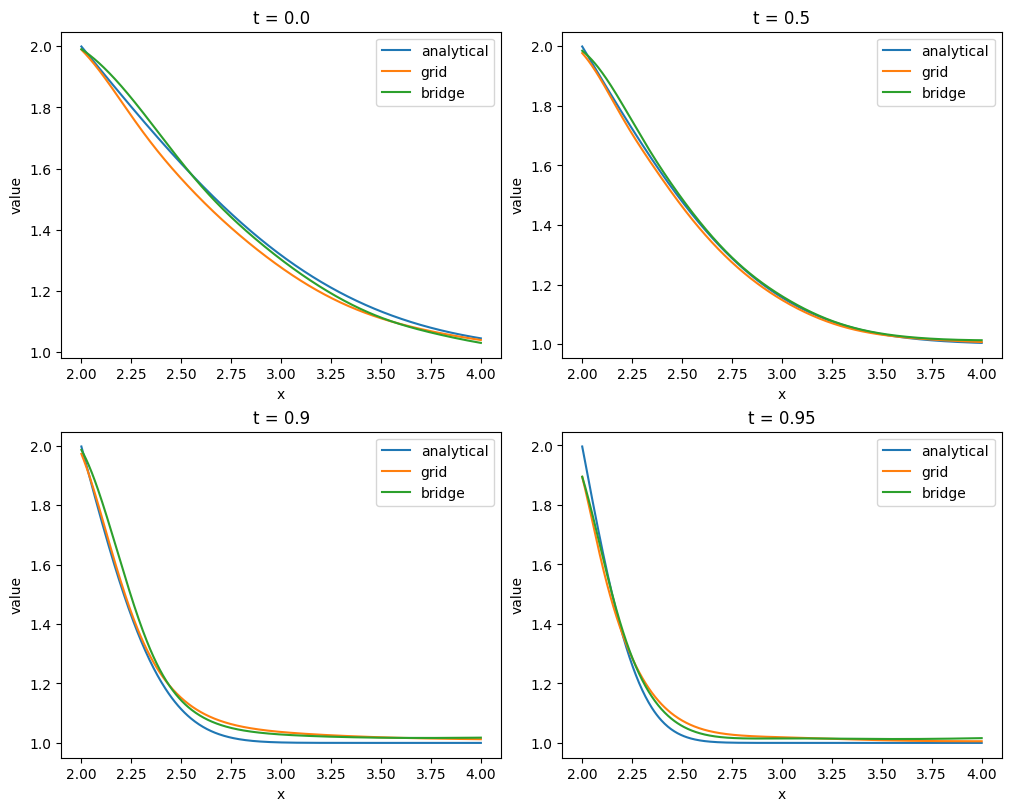

In [16]:
x_plot = torch.linspace(
    2.001,
    CFG.n2_x_max,
    500,
    device=DEVICE,
    dtype=DTYPE,
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8),
    constrained_layout=True,
)

for ax, t in zip(axes.flat, CFG.validation_times):
    exact = exact_singleton(2, t, x_plot)
    grid = grid_singleton.value(t, x_plot)
    bridge = models2[1].value(t, x_plot)

    ax.plot(to_numpy(x_plot), to_numpy(exact), label="analytical")
    ax.plot(to_numpy(x_plot), to_numpy(grid), label="grid")
    ax.plot(to_numpy(x_plot), to_numpy(bridge), label="bridge")
    ax.set_title(f"t = {t}")
    ax.set_xlabel("x")
    ax.set_ylabel("value")
    ax.legend()

fig.savefig(
    RESULTS / "N2_singleton_monitoring.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

### N2 reference

In [17]:
@torch.no_grad()
def exact_n2_domain(points: Tensor) -> Tensor:
    small = points.min(dim=1).values
    large = points.max(dim=1).values
    boundary = CFG.alpha * exact_singleton(2, 0.0, large)
    return small > boundary


@torch.no_grad()
def reference_payoff(points: Tensor, dW: Tensor) -> Tensor:
    p = points.shape[0]
    paths = dW.shape[0]
    steps = dW.shape[1]

    x = points[:, None, :].expand(p, paths, 2).clone()
    active = torch.ones(p, paths, device=DEVICE, dtype=torch.bool)
    payoff = torch.zeros(p, paths, device=DEVICE, dtype=DTYPE)

    dt = CFG.T / steps

    for k in range(steps + 1):
        t = k * dt

        small = x.min(dim=2).values
        large = x.max(dim=2).values
        boundary = CFG.alpha * exact_singleton(2, t, large)

        hit = active & (small <= boundary)

        if bool(hit.any()):
            payoff[hit] = exact_singleton(2, t, large[hit])
            active[hit] = False

        if k < steps:
            x = x + CFG.sigma * dW[:, k][None, :, :]

    return payoff


@torch.no_grad()
def reference_surface(points: Tensor, mask: Tensor, dW: Tensor, half: int):
    value = exact_singleton(2, 0.0, points.max(dim=1).values)
    se = torch.zeros_like(value)

    inside = points[mask]
    estimates = []
    errors = []

    for start in range(0, len(inside), CFG.reference_point_batch):
        chunk = inside[start:start + CFG.reference_point_batch]
        sample = reference_payoff(chunk, dW)

        pair = 0.5 * (sample[:, :half] + sample[:, half:])

        estimates.append(pair.mean(dim=1))
        errors.append(
            pair.std(dim=1, unbiased=True) / math.sqrt(half)
        )

    value[mask] = torch.cat(estimates)
    se[mask] = torch.cat(errors)

    return value, se


@torch.no_grad()
def make_reference():
    axis = torch.linspace(
        CFG.x_min,
        CFG.n2_x_max,
        CFG.reference_grid,
        device=DEVICE,
        dtype=DTYPE,
    )

    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack((x1.reshape(-1), x2.reshape(-1)), dim=1)
    mask = exact_n2_domain(points)

    fine = CFG.reference_fine_steps
    coarse = CFG.reference_coarse_steps

    if fine % coarse:
        raise ValueError("fine steps must divide into coarse steps")

    half = CFG.reference_paths // 2
    g = make_generator(SEED + 20_000)

    normal = torch.randn(
        half,
        fine,
        2,
        generator=g,
        device=DEVICE,
        dtype=DTYPE,
    )
    normal = torch.cat((normal, -normal))

    fine_dW = math.sqrt(CFG.T / fine) * normal

    block = fine // coarse
    coarse_dW = fine_dW.reshape(
        CFG.reference_paths,
        coarse,
        block,
        2,
    ).sum(dim=2)

    ref40, se40 = reference_surface(points, mask, coarse_dW, half)
    ref400, se400 = reference_surface(points, mask, fine_dW, half)

    ratio = math.sqrt(fine / coarse)
    rich = ref400 + (ref400 - ref40) / (ratio - 1.0)

    learned = completed_value(
        2,
        2,
        0.0,
        points,
        models2,
    )

    return axis, points, mask, learned, ref40, ref400, rich, se40, se400


(
    reference_axis,
    reference_points,
    reference_mask,
    learned_n2,
    reference_40,
    reference_400,
    reference_richardson,
    se_40,
    se_400,
) = make_reference()

In [18]:
def error_row(name, learned, reference, mask, se=None):
    error = learned[mask] - reference[mask]

    row = {
        "reference": name,
        "MAE": error.abs().mean().item(),
        "RMSE": error.square().mean().sqrt().item(),
        "max error": error.abs().max().item(),
        "signed mean": error.mean().item(),
    }

    if se is not None:
        row["mean MC SE"] = se[mask].mean().item()
        row["max MC SE"] = se[mask].max().item()
    else:
        row["mean MC SE"] = math.nan
        row["max MC SE"] = math.nan

    return row


reference_table = pd.DataFrame([
    error_row("40", learned_n2, reference_40, reference_mask, se_40),
    error_row("400", learned_n2, reference_400, reference_mask, se_400),
    error_row(
        "Richardson",
        learned_n2,
        reference_richardson,
        reference_mask,
    ),
])

show_table(reference_table)

reference_table.to_csv(
    RESULTS / "N2_reference_table.csv",
    index=False,
)

movement = pd.DataFrame({
    "comparison": ["40 to 400", "400 to Richardson"],
    "MAE": [
        (
            reference_40[reference_mask]
            - reference_400[reference_mask]
        ).abs().mean().item(),
        (
            reference_400[reference_mask]
            - reference_richardson[reference_mask]
        ).abs().mean().item(),
    ],
})

show_table(movement)

movement.to_csv(
    RESULTS / "N2_reference_movement.csv",
    index=False,
)

reference,MAE,RMSE,max error,signed mean,mean MC SE,max MC SE
40,0.058700,0.071100,0.242400,0.055200,0.009600,0.013700
400,0.020300,0.028500,0.141800,0.014800,0.009400,0.013500
Richardson,0.012700,0.017600,0.098000,-0.003900,nan,nan


comparison,MAE
40 to 400,0.040400
400 to Richardson,0.018700


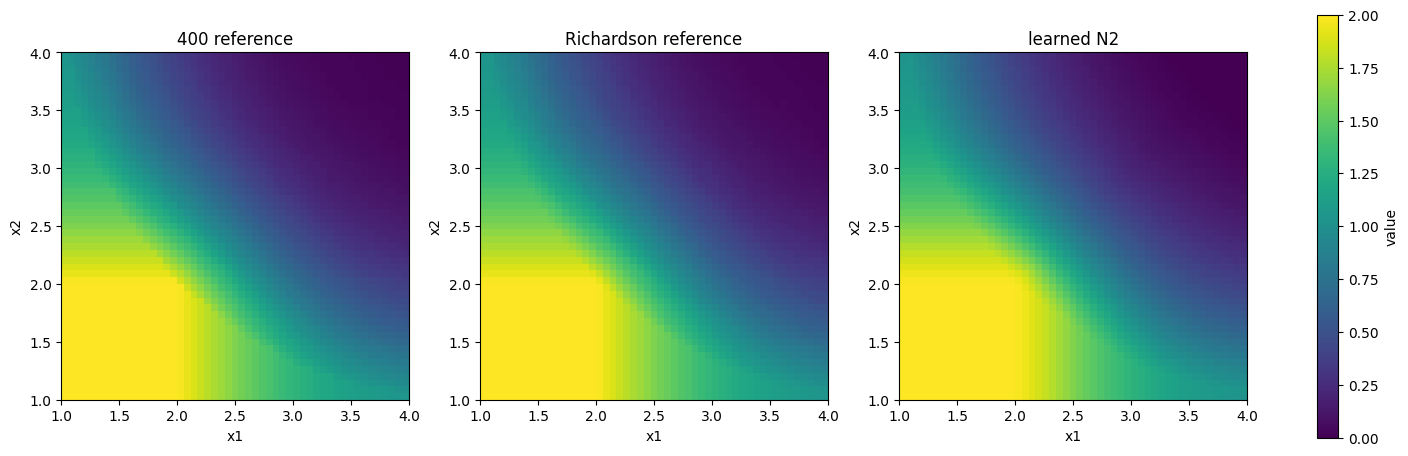

In [19]:
axis = to_numpy(reference_axis)
size = CFG.reference_grid

arrays = [
    to_numpy(reference_400).reshape(size, size),
    to_numpy(reference_richardson).reshape(size, size),
    to_numpy(learned_n2).reshape(size, size),
]

titles = [
    "400 reference",
    "Richardson reference",
    "learned N2",
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
    constrained_layout=True,
)

for ax, values, title in zip(axes, arrays, titles):
    image = ax.imshow(
        values.T,
        origin="lower",
        extent=(axis[0], axis[-1], axis[0], axis[-1]),
        aspect="equal",
        vmin=0.0,
        vmax=2.0,
    )
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig.colorbar(
    image,
    ax=axes,
    label="value",
)

fig.savefig(
    RESULTS / "N2_reference_fields.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

## N3

In [20]:
models3, training3 = train_cascade(
    3,
    CFG.n3_x_max,
    SEED + 5_000,
)

for level, model in models3.items():
    torch.save(
        model.state_dict(),
        RESULTS / f"N3_level{level}.pt",
    )

save_training(3, training3)

n3_training = training_table(3, training3)
show_table(n3_training)

n3_training.to_csv(
    RESULTS / "N3_training_table.csv",
    index=False,
)

N 3 level 1 1000 1.7605e-01
N 3 level 1 2000 5.0086e-02
N 3 level 1 3000 3.0974e-02
N 3 level 1 4000 2.4816e-02
N 3 level 1 5000 1.7761e-02
N 3 level 1 6000 1.8498e-02
N 3 level 1 7000 1.4595e-02
N 3 level 1 8000 1.3878e-02
N 3 level 1 9000 1.2235e-02
N 3 level 1 10000 1.1987e-02
N 3 level 1 11000 1.1294e-02
N 3 level 1 12000 1.0853e-02
N 3 level 1 13000 1.0401e-02
N 3 level 1 14000 1.0834e-02
N 3 level 1 15000 1.0253e-02
N 3 level 2 1000 2.9610e-01
N 3 level 2 2000 2.1391e-01
N 3 level 2 3000 1.2467e-01
N 3 level 2 4000 8.5714e-02
N 3 level 2 5000 5.5709e-02
N 3 level 2 6000 3.6680e-02
N 3 level 2 7000 2.6900e-02
N 3 level 2 8000 2.2535e-02
N 3 level 2 9000 1.9455e-02
N 3 level 2 10000 1.7242e-02
N 3 level 2 11000 1.6012e-02
N 3 level 2 12000 1.7057e-02
N 3 level 2 13000 1.5604e-02
N 3 level 2 14000 1.3514e-02
N 3 level 2 15000 1.3090e-02
N 3 level 3 1000 4.4068e-01
N 3 level 3 2000 3.4571e-01
N 3 level 3 3000 2.3461e-01
N 3 level 3 4000 1.9434e-01
N 3 level 3 5000 1.6971e-01
N 3 leve

N,level,best iteration,best validation,stopped,living,exit,boundary,near_terminal,range,monotonicity
3,1,14800,0.009900,0.004700,0.000100,0.023300,0.000500,0.002300,0.000000,0.000000
3,2,15000,0.013100,0.007500,0.000200,0.025600,0.001200,0.001700,0.000000,0.000000
3,3,15000,0.032400,0.020700,0.000400,0.043800,0.003100,0.004100,0.000000,0.000100


### N3 singleton

In [21]:
n3_singleton = singleton_table(
    3,
    models3[1],
    CFG.n3_x_max,
)

show_table(n3_singleton)

n3_singleton.to_csv(
    RESULTS / "N3_singleton_full_range.csv",
    index=False,
)

# Same evaluation window as the earlier N3 check.
n3_old_range = singleton_table(
    3,
    models3[1],
    5.0,
)

show_table(n3_old_range)

n3_old_range.to_csv(
    RESULTS / "N3_singleton_old_range.csv",
    index=False,
)

time,MAE,RMSE,max error,signed mean,Z MAE
0.000000,0.013200,0.019500,0.047300,0.011700,0.030800
0.500000,0.012400,0.018600,0.065600,0.005200,0.044200
0.900000,0.008700,0.011700,0.044300,0.001500,0.040400
0.950000,0.014100,0.027500,0.118100,-0.011300,0.043100


time,MAE,RMSE,max error,signed mean,Z MAE
0.000000,0.022200,0.027200,0.047300,0.021600,0.054400
0.500000,0.017900,0.025300,0.065600,0.017200,0.082800
0.900000,0.011000,0.015000,0.044300,0.009400,0.075400
0.950000,0.019700,0.037800,0.118100,-0.014100,0.082900


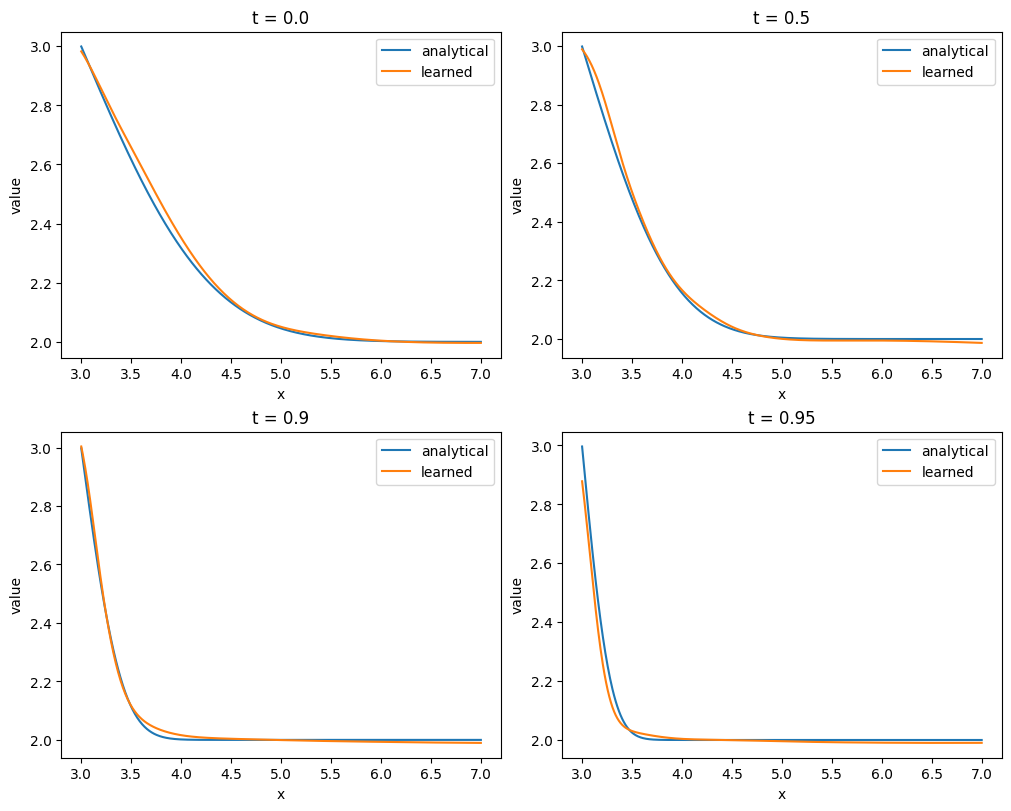

In [22]:
x = torch.linspace(
    3.001,
    CFG.n3_x_max,
    500,
    device=DEVICE,
    dtype=DTYPE,
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(10, 8),
    constrained_layout=True,
)

for ax, t in zip(axes.flat, CFG.validation_times):
    exact = exact_singleton(3, t, x)
    learned = models3[1].value(t, x)

    ax.plot(to_numpy(x), to_numpy(exact), label="analytical")
    ax.plot(to_numpy(x), to_numpy(learned), label="learned")

    ax.set_title(f"t = {t}")
    ax.set_xlabel("x")
    ax.set_ylabel("value")
    ax.legend()

fig.savefig(
    RESULTS / "N3_singleton.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

### N3 moving boundary

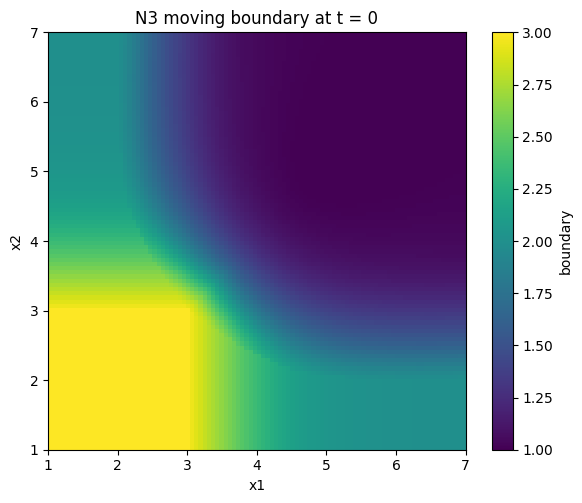

In [23]:
axis = torch.linspace(
    1.0,
    CFG.n3_x_max,
    100,
    device=DEVICE,
    dtype=DTYPE,
)

x1, x2 = torch.meshgrid(
    axis,
    axis,
    indexing="ij",
)

points = torch.stack(
    (x1.reshape(-1), x2.reshape(-1)),
    dim=1,
)

boundary = completed_value(
    3,
    2,
    0.0,
    points,
    models3,
)

# This is the frozen geometry used by level 3.
boundary = CFG.alpha * boundary.clamp(1.0, 3.0)

boundary = to_numpy(boundary).reshape(100, 100)
axis_np = to_numpy(axis)

fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(
    boundary.T,
    origin="lower",
    extent=(
        axis_np[0],
        axis_np[-1],
        axis_np[0],
        axis_np[-1],
    ),
    aspect="equal",
    vmin=1.0,
    vmax=3.0,
)

fig.colorbar(image, ax=ax, label="boundary")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("N3 moving boundary at t = 0")

fig.tight_layout()

fig.savefig(
    RESULTS / "N3_boundary_t0.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

### N3 to N2 reduction

In [24]:
@torch.no_grad()
def projection_check(far_values=(6.0, 7.0)):
    g = make_generator(SEED + 40_000)

    retained = uniform(
        (CFG.projection_samples, 2),
        2.5,
        CFG.n2_x_max,
        g,
    )

    rows = []

    for L in far_values:
        far = torch.full(
            (CFG.projection_samples, 1),
            L,
            device=DEVICE,
            dtype=DTYPE,
        )

        x3 = torch.cat((retained, far), dim=1)

        n2_value = completed_value(
            2,
            2,
            0.0,
            retained,
            models2,
        )

        n3_value = completed_value(
            3,
            3,
            0.0,
            x3,
            models3,
        )

        field_error = n3_value - n2_value

        survivor = retained[:, 0:1]

        n2_boundary = completed_value(
            2,
            1,
            0.0,
            survivor,
            models2,
        ).clamp(1.0, 2.0)

        n2_boundary = CFG.alpha * n2_boundary

        n3_survivor = torch.cat(
            (survivor, far),
            dim=1,
        )

        n3_boundary = completed_value(
            3,
            2,
            0.0,
            n3_survivor,
            models3,
        ).clamp(1.0, 3.0)

        n3_boundary = CFG.alpha * n3_boundary

        boundary_error = n3_boundary - n2_boundary

        z = (
            CFG.alpha * 3.0 - L
        ) / (
            CFG.sigma * math.sqrt(CFG.T)
        )

        hit_bound = 1.0 + math.erf(
            z / math.sqrt(2.0)
        )

        rows.append({
            "L": L,
            "hit bound": hit_bound,
            "field MAE": field_error.abs().mean().item(),
            "field RMSE": field_error.square().mean().sqrt().item(),
            "boundary MAE": boundary_error.abs().mean().item(),
            "boundary RMSE": boundary_error.square().mean().sqrt().item(),
        })

    return pd.DataFrame(rows)


projection = projection_check()

show_table(projection)

projection.to_csv(
    RESULTS / "N3_to_N2_projection.csv",
    index=False,
)

L,hit bound,field MAE,field RMSE,boundary MAE,boundary RMSE
6.000000,0.002700,0.018300,0.022600,0.012400,0.012900
7.000000,0.000100,0.010900,0.014400,0.010400,0.011000


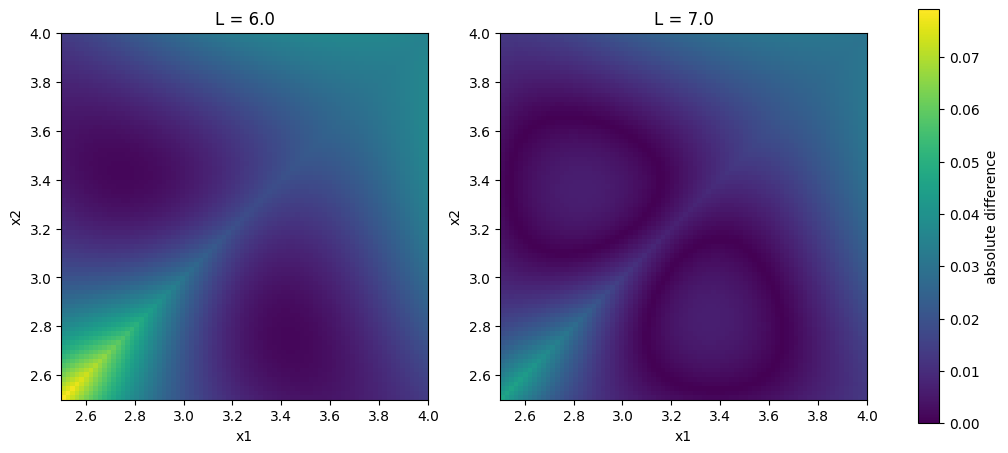

In [25]:
axis = torch.linspace(
    2.5,
    4.0,
    80,
    device=DEVICE,
    dtype=DTYPE,
)

x1, x2 = torch.meshgrid(
    axis,
    axis,
    indexing="ij",
)

points2 = torch.stack(
    (x1.reshape(-1), x2.reshape(-1)),
    dim=1,
)

n2 = completed_value(
    2,
    2,
    0.0,
    points2,
    models2,
)

errors = []

for L in (6.0, 7.0):
    far = torch.full(
        (points2.shape[0], 1),
        L,
        device=DEVICE,
        dtype=DTYPE,
    )

    points3 = torch.cat(
        (points2, far),
        dim=1,
    )

    n3 = completed_value(
        3,
        3,
        0.0,
        points3,
        models3,
    )

    errors.append(
        torch.abs(n3 - n2)
    )

vmax = max(
    error.max().item()
    for error in errors
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 4.5),
    constrained_layout=True,
)

axis_np = to_numpy(axis)

for ax, L, error in zip(
    axes,
    (6.0, 7.0),
    errors,
):
    values = to_numpy(error).reshape(80, 80)

    image = ax.imshow(
        values.T,
        origin="lower",
        extent=(
            axis_np[0],
            axis_np[-1],
            axis_np[0],
            axis_np[-1],
        ),
        aspect="equal",
        vmin=0.0,
        vmax=vmax,
    )

    ax.set_title(f"L = {L}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

fig.colorbar(
    image,
    ax=axes,
    label="absolute difference",
)

fig.savefig(
    RESULTS / "N3_to_N2_reduction.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

## Multiple boundary check

The check samples states where at least two learned margins lie in \([-0.05,0]\), so it is localised just outside simultaneous moving boundaries.

In [26]:
kink_results = pd.DataFrame([
    kink_check(
        2,
        2,
        models2,
        CFG.n2_x_max,
    ),
    kink_check(
        3,
        2,
        models3,
        CFG.n3_x_max,
    ),
    kink_check(
        3,
        3,
        models3,
        CFG.n3_x_max,
    ),
])

show_table(kink_results)

kink_results.to_csv(
    RESULTS / "multiple_boundary_check.csv",
    index=False,
)

N,level,near kink points,mean spread,max spread
2,2,264,0.000000,0.000000
3,2,74,0.000000,0.000000
3,3,213,0.000100,0.019600


## Parameters and summary

In [27]:
kappa = CFG.alpha / (
    CFG.sigma * math.sqrt(CFG.T)
)

parameter_table = pd.DataFrame({
    "quantity": [
        "alpha",
        "sigma",
        "T",
        "kappa",
        "kappa N for N2",
        "kappa N for N3",
    ],
    "value": [
        CFG.alpha,
        CFG.sigma,
        CFG.T,
        kappa,
        2.0 * kappa,
        3.0 * kappa,
    ],
})

show_table(parameter_table)

parameter_table.to_csv(
    RESULTS / "parameters.csv",
    index=False,
)

quantity,value
alpha,1.000000
sigma,1.000000
T,1.000000
kappa,1.000000
kappa N for N2,2.000000
kappa N for N3,3.000000


In [28]:
summary = pd.DataFrame({
    "quantity": [
        "N2 grid singleton MAE at t 0",
        "N2 bridge singleton MAE at t 0",
        "N2 field MAE against 40 reference",
        "N2 field MAE against 400 reference",
        "N2 field MAE against Richardson reference",
        "N3 singleton MAE at t 0 on old range",
        "N3 to N2 field MAE at L 6",
        "N3 to N2 field MAE at L 7",
        "N3 level 3 kink mean spread",
        "N3 level 3 kink max spread",
    ],
    "value": [
        grid_metrics.loc[
            grid_metrics["time"] == 0.0,
            "MAE",
        ].iloc[0],
        bridge_metrics.loc[
            bridge_metrics["time"] == 0.0,
            "MAE",
        ].iloc[0],
        reference_table.loc[
            reference_table["reference"] == "40",
            "MAE",
        ].iloc[0],
        reference_table.loc[
            reference_table["reference"] == "400",
            "MAE",
        ].iloc[0],
        reference_table.loc[
            reference_table["reference"] == "Richardson",
            "MAE",
        ].iloc[0],
        n3_old_range.loc[
            n3_old_range["time"] == 0.0,
            "MAE",
        ].iloc[0],
        projection.loc[
            projection["L"] == 6.0,
            "field MAE",
        ].iloc[0],
        projection.loc[
            projection["L"] == 7.0,
            "field MAE",
        ].iloc[0],
        kink_results.loc[
            (kink_results["N"] == 3)
            & (kink_results["level"] == 3),
            "mean spread",
        ].iloc[0],
        kink_results.loc[
            (kink_results["N"] == 3)
            & (kink_results["level"] == 3),
            "max spread",
        ].iloc[0],
    ],
})

show_table(summary)

summary.to_csv(
    RESULTS / "summary.csv",
    index=False,
)

print("saved to", RESULTS.resolve())

quantity,value
N2 grid singleton MAE at t 0,0.029600
N2 bridge singleton MAE at t 0,0.015800
N2 field MAE against 40 reference,0.058700
N2 field MAE against 400 reference,0.020300
N2 field MAE against Richardson reference,0.012700
N3 singleton MAE at t 0 on old range,0.022200
N3 to N2 field MAE at L 6,0.018300
N3 to N2 field MAE at L 7,0.010900
N3 level 3 kink mean spread,0.000100
N3 level 3 kink max spread,0.019600


saved to /content/cascade_results
